In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
data = pd.read_csv('data/train.csv')

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

A lot of NaNs in "Cabin", way better in "Embarked" and kinda bed in "Sex" 


Let's check how many people actually survived on some plots.

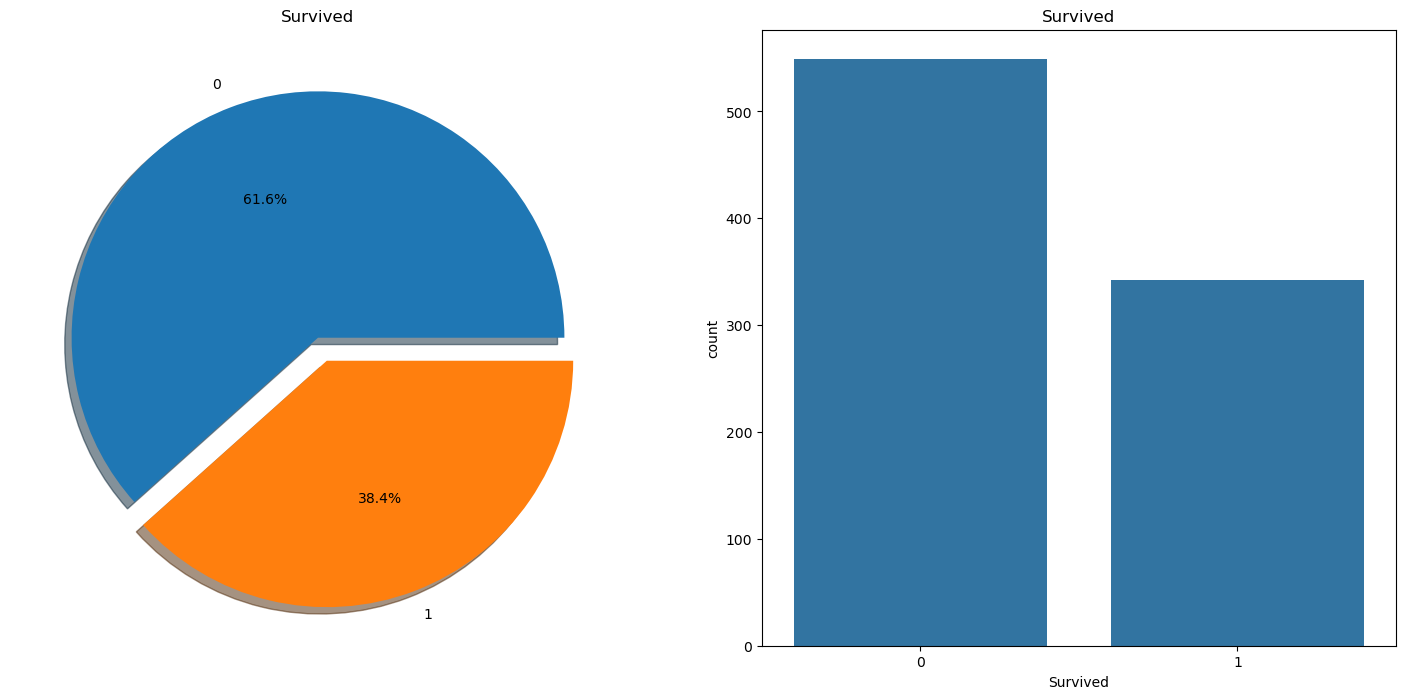

In [6]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
data['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_ylabel('')
ax[0].set_title('Survived')
sns.countplot(x='Survived', data=data, ax=ax[1])
ax[1].set_title('Survived')
plt.show()

We can see that 61.6% of passengers couldn't make it. Only 38.4% of passengers actually survived after a disaster. Let's check survival rate depending on other features in dataset.
First insights are - Age, Pclass, Sex, ParCH, SibSp.

Let's check survival rate based on sex.

In [7]:
data.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

Let's visualize our results.

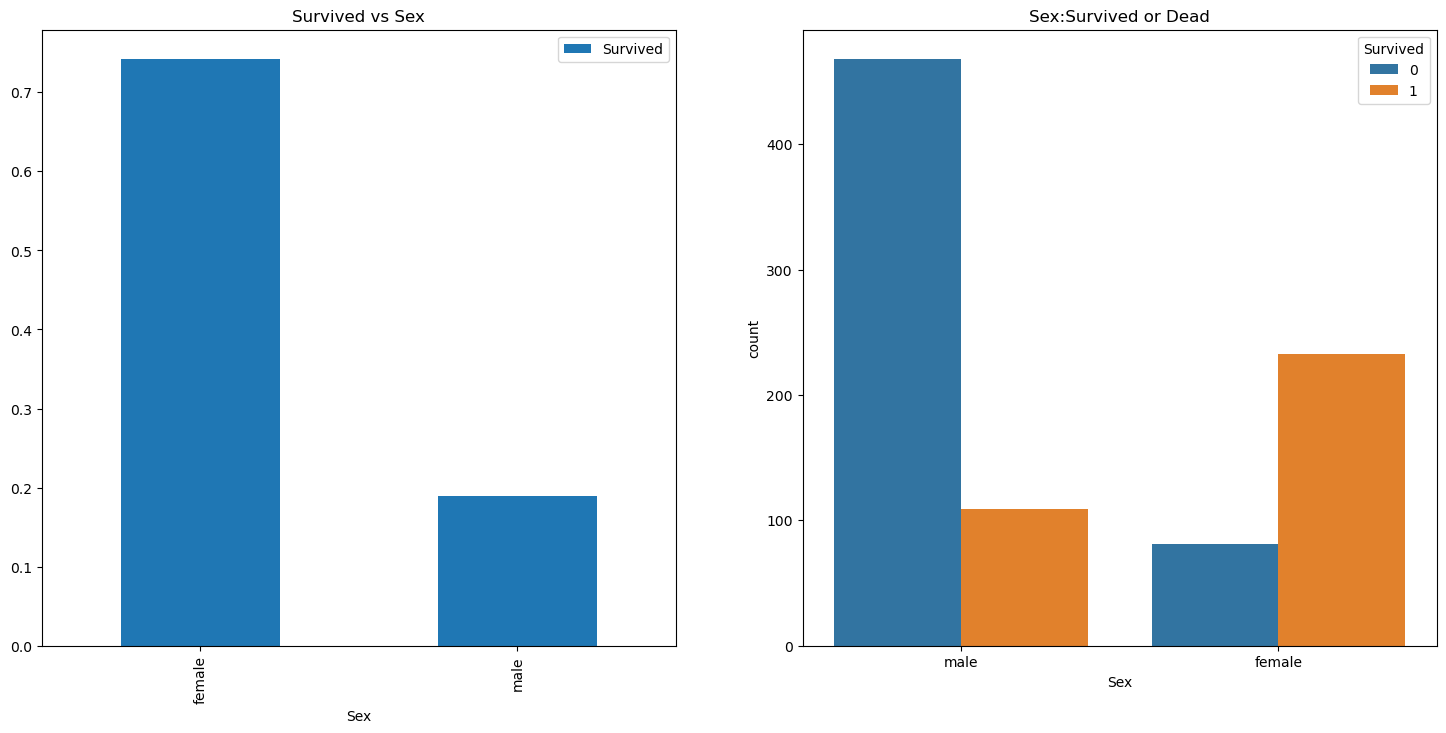

In [8]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
data[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex', hue='Survived', data=data, ax=ax[1])
ax[1].set_title('Sex:Survived or Dead')
plt.show()

Now we can see that number of men on the ship is A LOT more than number of women. Interesting that number of woman saved is as twice as the number of men saved. Survival rate for women is almost 75%, while that for men is at ~18%

P-class check

In [9]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


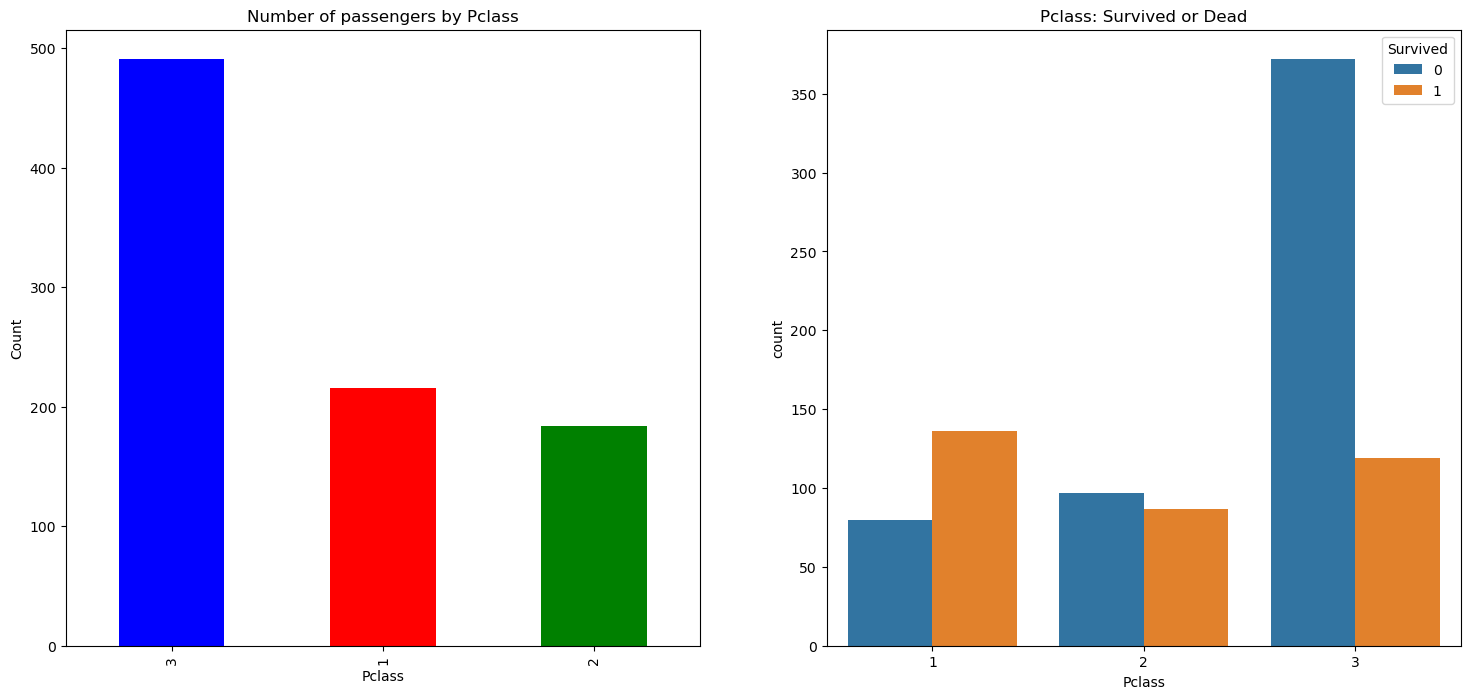

In [10]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
data['Pclass'].value_counts().plot.bar(color=['blue', 'red', 'green'], ax=ax[0])
ax[0].set_title('Number of passengers by Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass', hue='Survived', data=data, ax=ax[1])
ax[1].set_title('Pclass: Survived or Dead')
plt.show()

We can see that better class correlates with better chances on surviving. For 3rd class survival rate is less than 30%, for 2nd class that is almost 50%, and for the 1st class survival rate is almost 66%.
Let's check other features for insights.

In [11]:
print(f'Oldest passenger was of {data['Age'].max()} years')
print(f'Youngest passenger was {data['Age'].min()} years')
print(f'Average age on the ship is {data['Age'].mean()} years')

Oldest passenger was of 80.0 years
Youngest passenger was 0.42 years
Average age on the ship is 29.69911764705882 years


Let's try to build age distribution on the ship.

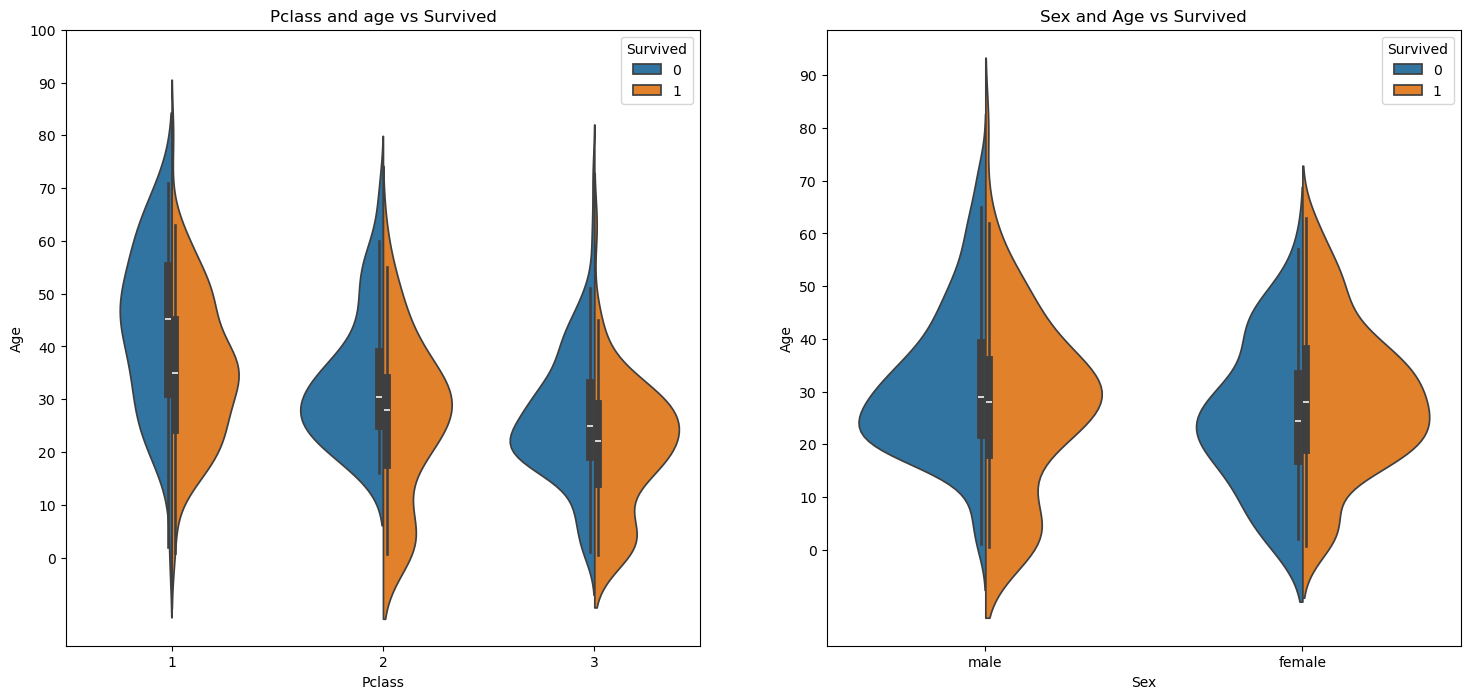

In [12]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=data, split=True, ax=ax[0])
ax[0].set_title('Pclass and age vs Survived')
ax[0].set_yticks(range(0, 110, 10))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=data, split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 100, 10))
plt.show()

We can see that survival rate across children is the same between Pclasses. Surival rate is pretty good for passengers aged 20-50 from Pclass 1, passengers aged around 30 from Pclass 2, and good for passengers aged around 25 from 3rd Pclass. These numbers are even higher for female passengers. Also, chances to survive for men are decreasing with their age.
Lets check SibSp

In [13]:
pd.crosstab(data.SibSp, data.Survived).style.background_gradient(cmap='PuBu')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


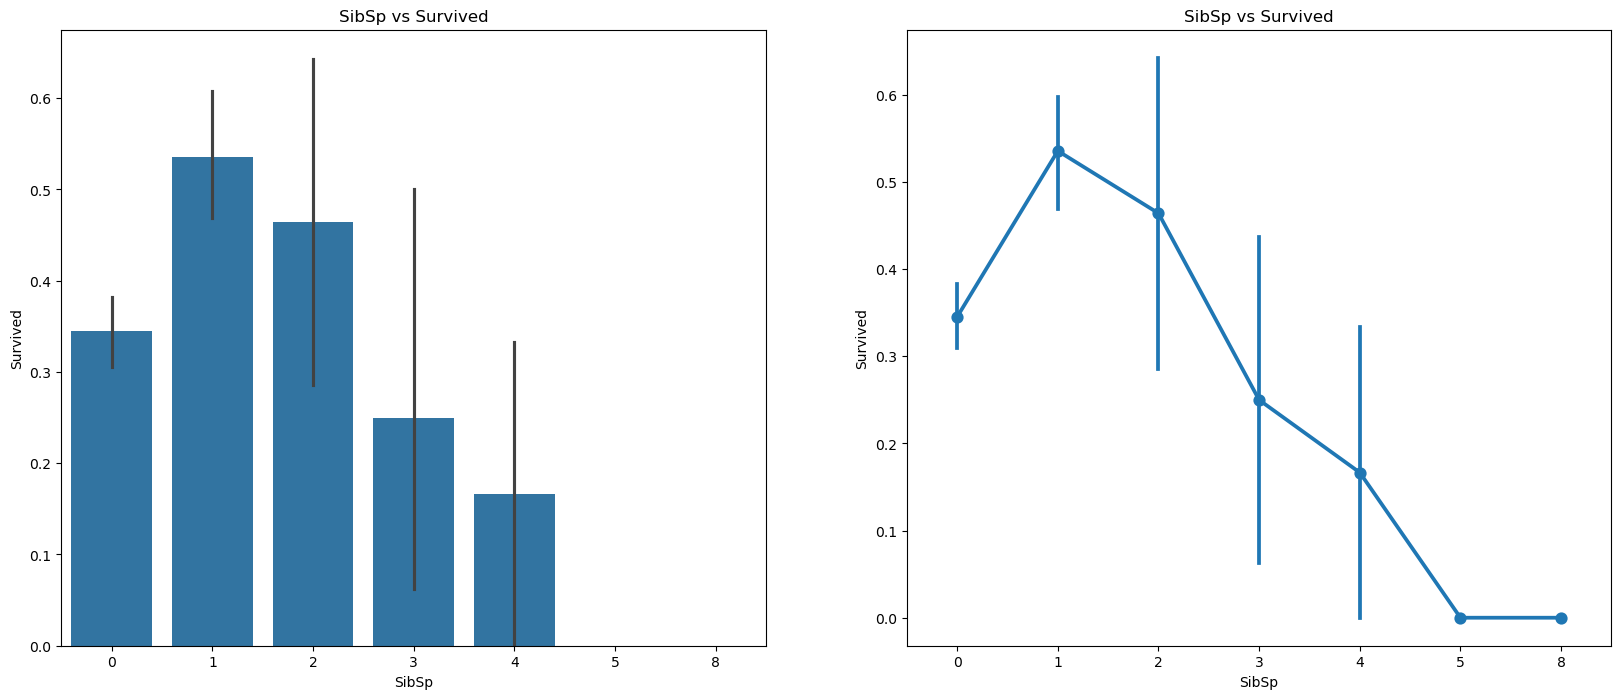

In [16]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot(x='SibSp',y='Survived',data=data,ax=ax[0])
ax[0].set_title('SibSp vs Survived')
sns.pointplot(x='SibSp',y='Survived',data=data,ax=ax[1])
ax[1].set_title('SibSp vs Survived')
plt.close(2)
plt.show()

Interesting results. Passengers with no family on the ship have 35% survival rate, while if they have wife/husband their chances increase to 53%. Surpisingly, with having more siblings on the ship your chances to survive are dropping to zero.

Results and observations:
1. Age - children do have a high chances of survival. Also, people between 15-35 years died a lot.
2. Pclass - we can see that with higher pclass your chances of survival are increasing.
3. Sex - chances of survival for women are significantly better than mens are.
4. Family features(ParCh + SibSp) - these two features should be unioned into Family feature for better results.

